<a href="https://colab.research.google.com/github/NazHub1993/ML_Notebooks/blob/main/Revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
data = {
    'hours_studied': [1, 2, 2, 3, 4, 4, 5, 6, 7, 8, 8, 9, 9, 10, 10],
    'attendance_%': [40, 50, 30, 60, 55, 70, 65, 75, 80, 85, 60, 90, 95, 85, 92],
    'prev_score':   [30, 40, 25, 50, 55, 60, 65, 70, 72, 80, 55, 88, 91, 85, 94],
    'pass':         [ 0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  0,  1,  1,  1,  1]
}

In [3]:
df=pd.DataFrame(data)
df.head()

,hours_studied,attendance_%,prev_score,pass
0,1,40,30,0
1,2,50,40,0
2,2,30,25,0
3,3,60,50,0
4,4,55,55,0


#Features and Target

In [25]:
X=df[['hours_studied','attendance_%','prev_score']]
Y=df['pass']

#Train_Test_Split

In [31]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.5,random_state=42)

#Creating my model

In [32]:
dt=DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=2,
    criterion='gini'
)

#Training the model

In [33]:
dt.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=2)

In [29]:
y_pred=dt.predict(x_test)

In [34]:
accuracy_score(y_test,y_pred)


1.0

In [56]:
from sklearn.model_selection import cross_val_score,StratifiedKFold

skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
scores=cross_val_score(dt,X,Y,cv=skf,scoring='accuracy')




print("CV scores:", scores)
print("Mean CV Accuracy:", scores.mean().round(2))

CV scores: [1.  0.6 0.8]
Mean CV Accuracy: 0.8


In [17]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00         1\n           1       1.00      1.00      1.00         2\n\n    accuracy                           1.00         3\n   macro avg       1.00      1.00      1.00         3\nweighted avg       1.00      1.00      1.00         3\n'

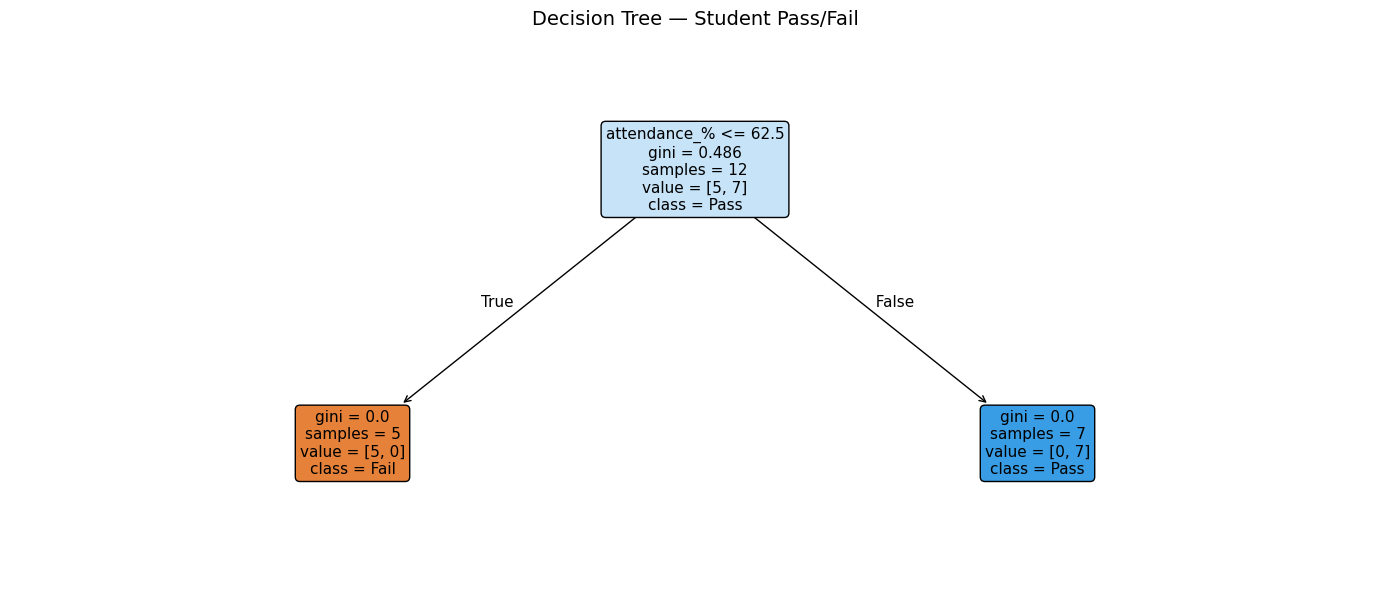

In [18]:
# ── 6. Visualize the Tree ───────────────────────────────
plt.figure(figsize=(14, 6))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['Fail', 'Pass'],
          filled=True,
          rounded=True,
          fontsize=11)
plt.title("Decision Tree — Student Pass/Fail", fontsize=14)
plt.tight_layout()
plt.show()

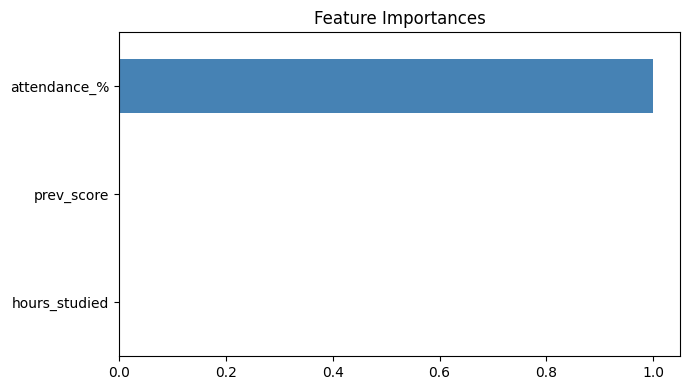

In [19]:
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='steelblue', figsize=(7, 4))
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf=RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=2,
    criterion='gini',
    oob_score=True,
    max_features='sqrt'
)

In [47]:
rf.fit(x_train,y_train)

RandomForestClassifier(max_depth=3, min_samples_leaf=2, oob_score=True)

In [48]:
y_pred=rf.predict(x_test)

In [49]:
accuracy_score(y_test,y_pred)

0.875

In [51]:
rf.oob_score_

0.7142857142857143

In [52]:
rf.feature_importances_

array([0.3512605 , 0.37492997, 0.27380952])

In [57]:
from sklearn.model_selection import GridSearchCV
param_grid={
    'n_estimators':[100,200],
    'max_depth':[3,2],
    'min_samples_leaf':[2,3],
    'criterion':['gini','entropy']

}


grid=GridSearchCV(rf,param_grid,cv=skf,scoring='accuracy')
grid.fit(x_train,y_train)
print(grid.best_params_)
print(grid.best_score_)


{'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 2, 'n_estimators': 100}
0.8333333333333334


In [58]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [60]:
from sklearn.svm import SVC

In [61]:
svm=SVC(kernel='rbf',C=1.0,gamma='scale',random_state=42)
svm.fit(x_train,y_train)


SVC(random_state=42)

In [62]:
y_pred=svm.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [63]:
accuracy_score(y_test,y_pred)

0.375

In [65]:
from sklearn.model_selection import cross_validate


In [67]:
result=cross_validate(svm,X,Y,cv=skf,scoring='accuracy')
result['test_score'].mean().round(2)

np.float64(0.93)